In [1]:
import torch
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

In [2]:
import torch
from torch_geometric.datasets import PPI

path = './data/PPI'

train_dataset = PPI(root=path, split='train')
val_dataset = PPI(root=path, split='val')
test_dataset = PPI(root=path, split='test')

print(f"Number of training graphs: {len(train_dataset)}")
print(f"Number of validation graphs: {len(val_dataset)}")
print(f"Number of test graphs: {len(test_dataset)}")
print(f"Number of node features: {train_dataset.num_features}")
print(f"Number of classes (labels per node): {train_dataset.num_classes}")

/home/filipe-silva/redes_grafos/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of training graphs: 20
Number of validation graphs: 2
Number of test graphs: 2
Number of node features: 50
Number of classes (labels per node): 121


In [3]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for batch in train_loader:
    print(batch)
    break

DataBatch(x=[1878, 50], edge_index=[2, 46268], y=[1878, 121], batch=[1878], ptr=[2])


## GCN ##

In [4]:
from torch_geometric.nn import GCNConv
from torch.nn import Linear
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn1 = GCNConv(train_dataset.num_features, 256) 
        self.gcn2 = GCNConv(256, 256)
        self.gcn3 = GCNConv(256, train_dataset.num_classes)

    def forward(self, x, adj,):
        x = self.gcn1(x, adj)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.gcn2(x, adj)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.gcn3(x, adj)
        return x

model = GCN()
print(model)

GCN(
  (gcn1): GCNConv(50, 256)
  (gcn2): GCNConv(256, 256)
  (gcn3): GCNConv(256, 121)
)


In [5]:
from sklearn.metrics import f1_score

def train(model,optimizer,criterion):# Training loop
    
    model.train()
    
    total_loss = 0 
    for data in train_loader:
        data = data.to("cuda")
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index)

        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
    return total_loss/len(train_loader.dataset)

def evaluate(model,criterion):
    with torch.no_grad():
        model.eval()
        total_loss = 0
        y_true = []
        y_pred = []

        for data in val_loader:
            data = data.to("cuda")
            out = model(data.x, data.edge_index)
            
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs
            
            probs = torch.sigmoid(out)
            
            preds = (probs > 0.5).float()
            
            y_true.append(data.y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

        # Concatenate all batches
        y_true = np.concatenate(y_true, axis=0)
        y_pred = np.concatenate(y_pred, axis=0)
        
        # Calculate average loss and Micro F1 Score
        avg_loss = total_loss / len(val_loader.dataset)
        micro_f1 = f1_score(y_true, y_pred, average='micro')
    
    return avg_loss, micro_f1


In [ ]:
model_gcn = GCN()
model_gcn.to(device="cuda")

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.005)

train_losses = []
val_losses = []
val_f1 = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

for epoch in range(200):
    loss = train(model_gcn, optimizer, criterion)
    
    val_los,val_score_f1 = evaluate(model_gcn,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los) 
    val_f1.append(val_score_f1)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f}')
    


Epoch   0 | Loss: 0.61 | ValLoss: 0.58
Epoch  10 | Loss: 0.53 | ValLoss: 0.53
Epoch  20 | Loss: 0.49 | ValLoss: 0.49
Epoch  30 | Loss: 0.48 | ValLoss: 0.48
Epoch  40 | Loss: 0.47 | ValLoss: 0.46
Epoch  50 | Loss: 0.46 | ValLoss: 0.45
Epoch  60 | Loss: 0.46 | ValLoss: 0.46
Epoch  70 | Loss: 0.46 | ValLoss: 0.45
Epoch  80 | Loss: 0.45 | ValLoss: 0.45
Epoch  90 | Loss: 0.44 | ValLoss: 0.44
Epoch 100 | Loss: 0.44 | ValLoss: 0.43
Epoch 110 | Loss: 0.44 | ValLoss: 0.43
Epoch 120 | Loss: 0.43 | ValLoss: 0.43
Epoch 130 | Loss: 0.43 | ValLoss: 0.43
Epoch 140 | Loss: 0.43 | ValLoss: 0.43
Epoch 150 | Loss: 0.43 | ValLoss: 0.43
Epoch 160 | Loss: 0.42 | ValLoss: 0.42
Epoch 170 | Loss: 0.43 | ValLoss: 0.43
Epoch 180 | Loss: 0.42 | ValLoss: 0.42
Epoch 190 | Loss: 0.42 | ValLoss: 0.41


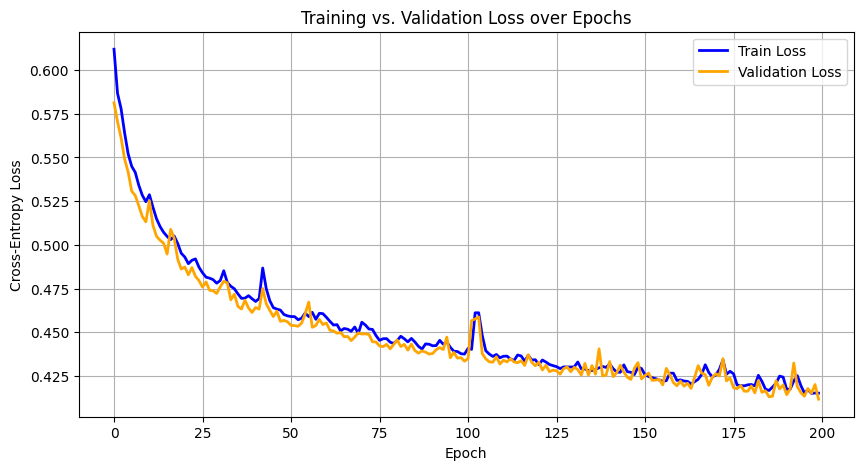

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

def test(model):
    with torch.no_grad():
        model.eval()
        y_true = []
        y_pred = []

        for data in test_loader:
            data = data.to("cuda")
            out = model(data.x, data.edge_index)
            
            probs = torch.sigmoid(out)
            
            preds = (probs > 0.5).float()
            
            y_true.append(data.y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

        y_true = np.concatenate(y_true, axis=0)
        y_pred = np.concatenate(y_pred, axis=0)
    
    return f1_score(y_true, y_pred, average='micro')

test_f1 = test(model_gcn)
print(f'Best f1 Score: {test_f1:.4f}')

Best f1 Score: 0.6525


: 

In [52]:
import torch
import gc

# Deleta o modelo antigo da memória do Python (substitua o nome se for diferente)
if 'model_gcn' in globals():
    del model_gcn

# Força o coletor de lixo do Python
gc.collect()

# Limpa o cache da placa de vídeo
torch.cuda.empty_cache()

print("Memória da GPU liberada!")

Memória da GPU liberada!


## GAT CONV ##

In [81]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(train_dataset.num_features, 128, heads=4) 
        self.gat2 = GATConv(128*4, 128, heads=4)
        self.gat3 = GATConv(128*4, train_dataset.num_classes, heads=6,concat = False)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = self.gat3(x, edge_index)
        return x

model = GAT()
print(model)


GAT(
  (gat1): GATConv(50, 128, heads=4)
  (gat2): GATConv(512, 128, heads=4)
  (gat3): GATConv(512, 121, heads=6)
)


In [ ]:
import copy

model_gat = GAT()
model_gat.to(device = "cuda")

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gat.parameters(),lr=0.005)

train_losses = []
val_losses = []
val_f1

best_val_f1 = 0.0
best_weights = None
best_epoch = 0

for epoch in range(200):
    loss = train(model_gat, optimizer, criterion)
    
    val_los, val_f1_score = evaluate(model_gat,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    val_f1.append(val_f1_score)
    
    if val_f1_score > best_val_f1:
        best_val_f1 = val_f1_score
        best_weights = copy.deepcopy(model_gat.state_dict())
        best_epoch = epoch
       
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | ValF1: {val_f1_score:.2f}')

model_gat.load_state_dict(best_weights)
print(f'Best validation accuracy: {best_val_f1:.4f} at epoch {best_epoch}')


Epoch   0 | Loss: 0.58 | ValLoss: 0.54 | ValF1: 0.42
Epoch  10 | Loss: 0.46 | ValLoss: 0.45 | ValF1: 0.58
Epoch  20 | Loss: 0.41 | ValLoss: 0.42 | ValF1: 0.62
Epoch  30 | Loss: 0.33 | ValLoss: 0.36 | ValF1: 0.72
Epoch  40 | Loss: 0.28 | ValLoss: 0.34 | ValF1: 0.71
Epoch  50 | Loss: 0.24 | ValLoss: 0.29 | ValF1: 0.78
Epoch  60 | Loss: 0.23 | ValLoss: 0.28 | ValF1: 0.79
Epoch  70 | Loss: 0.20 | ValLoss: 0.26 | ValF1: 0.82
Epoch  80 | Loss: 0.17 | ValLoss: 0.28 | ValF1: 0.82
Epoch  90 | Loss: 0.15 | ValLoss: 0.24 | ValF1: 0.84
Epoch 100 | Loss: 0.16 | ValLoss: 0.24 | ValF1: 0.84
Epoch 110 | Loss: 0.14 | ValLoss: 0.27 | ValF1: 0.81
Epoch 120 | Loss: 0.17 | ValLoss: 0.25 | ValF1: 0.84
Epoch 130 | Loss: 0.12 | ValLoss: 0.23 | ValF1: 0.86
Epoch 140 | Loss: 0.13 | ValLoss: 0.23 | ValF1: 0.86
Epoch 150 | Loss: 0.10 | ValLoss: 0.20 | ValF1: 0.88
Epoch 160 | Loss: 0.10 | ValLoss: 0.21 | ValF1: 0.88
Epoch 170 | Loss: 0.10 | ValLoss: 0.22 | ValF1: 0.87
Epoch 180 | Loss: 0.10 | ValLoss: 0.21 | ValF1

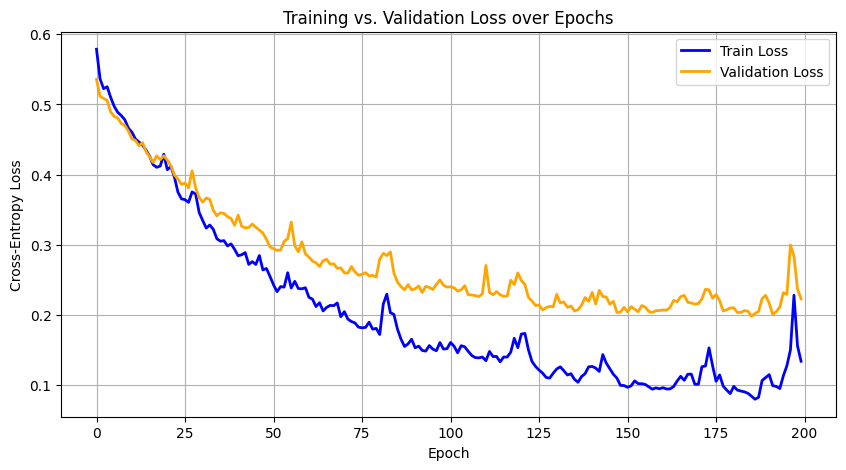

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [87]:
test_f1 = test(model_gat)
print(f'Test Accuracy: {test_f1:.4f}')

Test Accuracy: 0.9188


In [80]:
import torch
import gc

# Deleta o modelo antigo da memória do Python (substitua o nome se for diferente)
if 'model_gat' in globals():
    del model_gat

# Força o coletor de lixo do Python
gc.collect()

# Limpa o cache da placa de vídeo
torch.cuda.empty_cache()

print("Memória da GPU liberada!")

Memória da GPU liberada!
